# IIC-3641 GML UC

- Versiones de librerías, python 3.10.2
- DGL: https://www.dgl.ai/pages/start.html

In [1]:
import torch
print(torch.__version__)

2.7.1+cu118


## DGL requiere de un framework de backend. Aquí va con torch sobre cuda (GPU).

In [2]:
import os

os.environ["DGLBACKEND"] = "pytorch"
import time
import warnings

import dgl
import dgl.function as fn
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from dgl.nn.functional import edge_softmax

warnings.filterwarnings("ignore", message="use_inf_as_na option is deprecated")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## ¿Cuándo sirve la atención?

GCN agrega a los vecinos con pesos **fijos**, que dependen solo de los grados: $\frac{1}{\sqrt{d_i d_j}}$. GAT los **aprende** a partir del contenido de los nodos, así que cada nodo puede decidir a qué vecinos escuchar.

Eso solo sirve si hay algo que decidir. En **Cora**, el 81% de las aristas unen nodos de la misma clase: promediarlos a todos ya es un buen filtro. Ahí GAT y GCN empatan, y la atención aprendida termina siendo casi uniforme (lo verificamos al final del notebook).

La atención debería marcar la diferencia cuando:
1. los vecinos **no son igual de relevantes**, y
2. el **contenido** de los nodos permite distinguir cuáles importan.

Un grafo donde se cumplen las dos cosas es **roman-empire** (Platonov et al., *A critical look at the evaluation of GNNs under heterophily*, ICLR 2023):
- cada nodo es una **palabra** del artículo *Roman Empire* de Wikipedia (22.662 palabras);
- dos palabras se conectan si son **consecutivas** en el texto o si hay una **dependencia sintáctica** entre ellas;
- las features son embeddings **fastText** (300 dimensiones) de cada palabra;
- la tarea es predecir el **rol sintáctico** de la palabra (18 clases: sujeto, objeto, determinante, preposición, ...).

Para saber si una palabra es sujeto, no sirve promediar a todas sus vecinas. Importa **cuál** de ellas es su núcleo sintáctico, y eso se reconoce por el contenido de la palabra.

## Leemos el dataset

El grafo viene con **10 particiones fijas** 50/25/25 (train/val/test). Usar las mismas particiones que el paper permite comparar resultados. Lo pasamos a no dirigido y agregamos self-loops, como es habitual en GAT: el nodo puede ponerse atención a sí mismo.

In [3]:
from dgl.data import RomanEmpireDataset

dataset = RomanEmpireDataset()
g = dataset[0]
g = dgl.to_bidirected(g, copy_ndata=True)
g = dgl.add_self_loop(dgl.remove_self_loop(g))

features = g.ndata["feat"]
labels = g.ndata["label"]
num_classes = dataset.num_classes
num_splits = g.ndata["train_mask"].shape[1]

src, dst = g.edges()
no_self = src != dst
homofilia_aristas = (labels[src[no_self]] == labels[dst[no_self]]).float().mean().item()
grado = g.in_degrees() - 1   # sin contar el self-loop

print(f"Nodos: {g.num_nodes():,}   |   aristas (sin self-loops, ambos sentidos): {int(no_self.sum()):,}")
print(f"Features: {features.shape[1]}   |   clases: {num_classes}   |   particiones: {num_splits}")
print(f"Grado medio: {grado.float().mean():.2f}   |   grado máximo: {grado.max().item()}")
print(f"Homofilia de aristas: {homofilia_aristas:.3f}   (Cora: 0.81)")

g = g.to(device)
features, labels = features.to(device), labels.to(device)

Done loading data from cached files.
Nodos: 22,662   |   aristas (sin self-loops, ambos sentidos): 65,854
Features: 300   |   clases: 18   |   particiones: 10
Grado medio: 2.91   |   grado máximo: 14
Homofilia de aristas: 0.047   (Cora: 0.81)


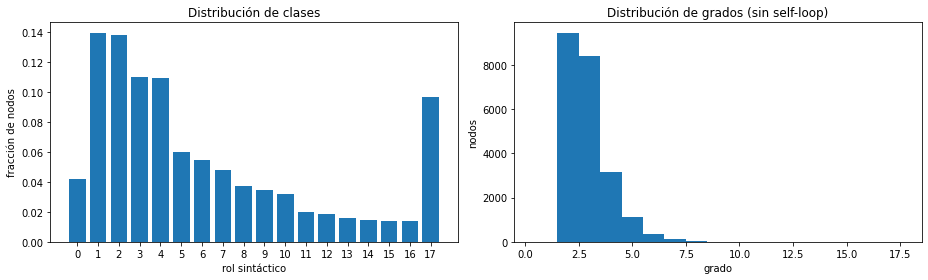

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

CLASES = [f"rol {c}" for c in range(num_classes)]   # el dataset no publica los nombres de los roles

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
frec = torch.bincount(labels.cpu(), minlength=num_classes).numpy()
axes[0].bar(range(num_classes), frec / frec.sum())
axes[0].set(title="Distribución de clases", xlabel="rol sintáctico", ylabel="fracción de nodos",
            xticks=range(num_classes))
axes[1].hist(grado.numpy(), bins=np.arange(0, 20) - 0.5)
axes[1].set(title="Distribución de grados (sin self-loop)", xlabel="grado", ylabel="nodos", xlim=(-0.5, 18.5))
plt.tight_layout()
plt.show()

**Lectura.**
- La **homofilia de aristas es 0.047**: menos del 5% de las aristas une dos palabras con el mismo rol. En Cora es 0.81. Esto no significa que los vecinos no sirvan: el rol de las palabras vecinas **sí** informa sobre el rol propio (un determinante suele ir antes de un sustantivo). Pero la información está en *qué rol tiene cuál vecino*, no en "ser parecido a los vecinos".
- Casi todas las palabras tienen grado 2 o 3: la anterior y la siguiente en el texto, más alguna dependencia sintáctica. Unas pocas llegan a 14. Son núcleos sintácticos con muchas palabras que dependen de ellos.
- Las 18 clases están desbalanceadas. Tres roles suman casi el 40% de los nodos, y varios no llegan al 2%.

## Definiremos una capa GAT

Para cada arista $j \to i$ y cada cabeza $k$:

1. **Proyección:** $z_j = W h_j$ (una proyección por cabeza).
2. **Puntaje:** $e_{ij} = \text{LeakyReLU}\big(a^\top [z_j \,\|\, z_i]\big)$. Si partimos $a = [a_{src} \,\|\, a_{dst}]$, esto es $\text{LeakyReLU}(a_{src}^\top z_j + a_{dst}^\top z_i)$. Así lo calculamos: un escalar por nodo en cada rol, que se suman en cada arista con `u_add_v`. Es más eficiente que concatenar vectores arista por arista.
3. **Softmax por vecindario:** $\alpha_{ij} = \text{softmax}_{j \in \mathcal{N}(i)}(e_{ij})$, con `edge_softmax`.
4. **Agregación:** $h_i' = \sum_j \alpha_{ij} z_j$, y se concatenan las cabezas.

La capa tiene dos interruptores, que son los que harán el experimento controlado:

- `uniforme=True` reemplaza los puntajes por ceros, así que el softmax da $\alpha_{ij} = 1/d_i$. **Mismos parámetros, misma arquitectura, sin atención.** Es el grupo de control: si GAT mejora sobre esta versión, la mejora es de la atención y no de otra cosa.
- `v2=True` usa **GATv2** (Brody et al., ICLR 2022): $e_{ij} = a^\top \text{LeakyReLU}(W_s h_j + W_d h_i)$. Más abajo explicamos por qué importa el cambio de orden.

Los $\alpha_{ij}$ de la última pasada quedan guardados en `self.alpha` para analizarlos.

In [5]:
class GATLayer(nn.Module):
    def __init__(self, dim, num_heads, uniforme=False, v2=False):
        super(GATLayer, self).__init__()
        self.H, self.d = num_heads, dim // num_heads
        self.uniforme, self.v2 = uniforme, v2
        self.fc = nn.Linear(dim, dim, bias=False)            # W (todas las cabezas juntas)
        self.a_src = nn.Parameter(torch.empty(1, self.H, self.d))
        if v2:
            self.fc_dst = nn.Linear(dim, dim, bias=False)    # W_d de GATv2
        else:
            self.a_dst = nn.Parameter(torch.empty(1, self.H, self.d))
        self.alpha = None
        self.reset_parameters()

    def reset_parameters(self):
        gain = nn.init.calculate_gain("relu")
        nn.init.xavier_normal_(self.fc.weight, gain=gain)
        nn.init.xavier_normal_(self.a_src, gain=gain)
        if self.v2:
            nn.init.xavier_normal_(self.fc_dst.weight, gain=gain)
        else:
            nn.init.xavier_normal_(self.a_dst, gain=gain)

    def forward(self, g, h):
        with g.local_scope():
            z = self.fc(h).view(-1, self.H, self.d)
            g.ndata["z"] = z
            if self.uniforme:
                e = torch.zeros(g.num_edges(), self.H, 1, device=h.device)
            elif self.v2:
                # e_ij = a^T LeakyReLU(W_s h_j + W_d h_i)
                g.ndata["zd"] = self.fc_dst(h).view(-1, self.H, self.d)
                g.apply_edges(fn.u_add_v("z", "zd", "s"))
                e = (F.leaky_relu(g.edata["s"], 0.2) * self.a_src).sum(-1, keepdim=True)
            else:
                # e_ij = LeakyReLU(a_src^T z_j + a_dst^T z_i)
                g.ndata["el"] = (z * self.a_src).sum(-1, keepdim=True)
                g.ndata["er"] = (z * self.a_dst).sum(-1, keepdim=True)
                g.apply_edges(fn.u_add_v("el", "er", "e"))
                e = F.leaky_relu(g.edata["e"], 0.2)
            alpha = edge_softmax(g, e)           # (aristas, cabezas, 1)
            self.alpha = alpha.detach()
            g.edata["a"] = alpha
            g.update_all(fn.u_mul_e("z", "a", "m"), fn.sum("m", "h"))
            return g.ndata["h"].reshape(-1, self.H * self.d)

## La red: el mismo esqueleto para todos los modelos

Para que la comparación sea justa, **todos los modelos comparten la misma arquitectura** y solo cambia la capa que agrega a los vecinos:

$$h \leftarrow h + \text{Dropout}\Big(\text{FFN}\big(\,\text{Agregar}(\text{LayerNorm}(h))\,\big)\Big)$$

| modelo | `Agregar` |
|---|---|
| MLP | nada: cada nodo se mira solo a sí mismo |
| GCN | `GraphConv` de DGL, pesos $1/\sqrt{d_i d_j}$ |
| GAT uniforme | nuestra `GATLayer` con `uniforme=True`, pesos $1/d_i$ |
| GAT | nuestra `GATLayer` |
| GATv2 | nuestra `GATLayer` con `v2=True` |

Las **conexiones residuales** ($h + \dots$) son importantes en grafos heterofílicos. Sin ellas, cada capa reemplaza la representación del nodo por un promedio de vecinos que en su mayoría son de otra clase. Con ellas, el nodo conserva su propia información y le *suma* lo que recoge del vecindario. Es la arquitectura del paper de Platonov et al.

In [6]:
from dgl.nn.pytorch import GraphConv


class SinGrafo(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.lin = nn.Linear(dim, dim)

    def forward(self, g, h):
        return self.lin(h)


class GCNLayer(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.conv = GraphConv(dim, dim)

    def forward(self, g, h):
        return self.conv(g, h)


CAPAS = {
    "MLP":          lambda d: SinGrafo(d),
    "GCN":          lambda d: GCNLayer(d),
    "GAT uniforme": lambda d: GATLayer(d, num_heads=8, uniforme=True),
    "GAT":          lambda d: GATLayer(d, num_heads=8),
    "GATv2":        lambda d: GATLayer(d, num_heads=8, v2=True),
}


class Net(nn.Module):
    def __init__(self, capa, in_dim, dim, out_dim, num_layers=3, dropout=0.2):
        super().__init__()
        self.inp = nn.Linear(in_dim, dim)
        self.convs = nn.ModuleList([CAPAS[capa](dim) for _ in range(num_layers)])
        self.norms = nn.ModuleList([nn.LayerNorm(dim) for _ in range(num_layers)])
        self.ffns = nn.ModuleList([nn.Sequential(nn.Linear(dim, dim), nn.GELU(), nn.Dropout(dropout),
                                                 nn.Linear(dim, dim)) for _ in range(num_layers)])
        self.drop = nn.Dropout(dropout)
        self.out = nn.Linear(dim, out_dim)

    def forward(self, g, x, return_hidden=False):
        h = self.inp(x)
        for conv, norm, ffn in zip(self.convs, self.norms, self.ffns):
            h = h + self.drop(ffn(F.gelu(conv(g, norm(h)))))
        return (self.out(h), h) if return_hidden else self.out(h)

## Definimos el ciclo de entrenamiento

Entrenamos con AdamW durante 400 épocas y cada 5 épocas evaluamos en validación. Nos quedamos con el modelo de mejor accuracy de **validación**; el test se mira una sola vez al final.

Epoch 00000 | Loss 2.8845 | Train Acc 0.1395 | Val Acc 0.1396
Epoch 00050 | Loss 0.5790 | Train Acc 0.8358 | Val Acc 0.7580
Epoch 00100 | Loss 0.1328 | Train Acc 0.9869 | Val Acc 0.7859
Epoch 00150 | Loss 0.0324 | Train Acc 0.9996 | Val Acc 0.7892
Epoch 00200 | Loss 0.0136 | Train Acc 0.9998 | Val Acc 0.7908
Epoch 00250 | Loss 0.0079 | Train Acc 0.9999 | Val Acc 0.7908
Epoch 00300 | Loss 0.0065 | Train Acc 0.9998 | Val Acc 0.7894
Epoch 00350 | Loss 0.0046 | Train Acc 0.9999 | Val Acc 0.7873

Tiempo: 11 s   |   parámetros: 676,114
Accuracy test (partición 0): 0.7864


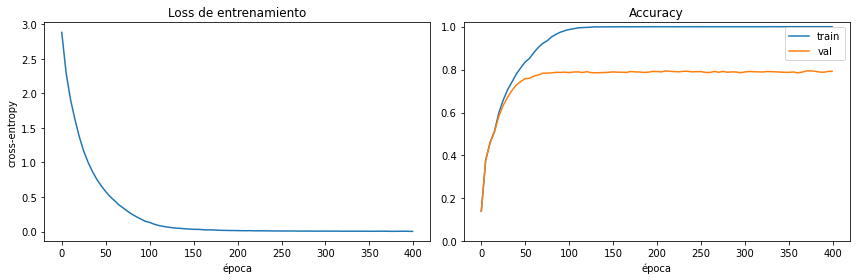

In [7]:
def masks(split):
    return [g.ndata[k][:, split].bool() for k in ("train_mask", "val_mask", "test_mask")]


def evaluate(model, mask):
    model.eval()
    with torch.no_grad():
        pred = model(g, features).argmax(1)
    return (pred[mask] == labels[mask]).float().mean().item()


def train(capa, split, seed=0, epochs=400, lr=1e-3, dim=256, verbose=False):
    train_mask, val_mask, test_mask = masks(split)
    torch.manual_seed(seed)
    model = Net(capa, features.shape[1], dim, num_classes).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    hist = {"epoch": [], "loss": [], "train_acc": [], "val_acc": []}
    best_val, best_state = -1.0, None
    for epoch in range(epochs):
        model.train()
        logits = model(g, features)
        loss = F.cross_entropy(logits[train_mask], labels[train_mask])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if epoch % 5 == 0 or epoch == epochs - 1:
            val_acc = evaluate(model, val_mask)
            hist["epoch"].append(epoch)
            hist["loss"].append(loss.item())
            hist["train_acc"].append(evaluate(model, train_mask))
            hist["val_acc"].append(val_acc)
            if val_acc > best_val:
                best_val = val_acc
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            if verbose and epoch % 50 == 0:
                print(f"Epoch {epoch:05d} | Loss {loss.item():.4f} | Train Acc {hist['train_acc'][-1]:.4f} | Val Acc {val_acc:.4f}")
    model.load_state_dict(best_state)
    model.eval()
    return model, hist


t0 = time.time()
net, hist = train("GAT", split=0, verbose=True)
print(f"\nTiempo: {time.time() - t0:.0f} s   |   parámetros: {sum(p.numel() for p in net.parameters()):,}")
_, _, test_mask0 = masks(0)
print(f"Accuracy test (partición 0): {evaluate(net, test_mask0):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist["epoch"], hist["loss"])
axes[0].set(title="Loss de entrenamiento", xlabel="época", ylabel="cross-entropy")
axes[1].plot(hist["epoch"], hist["train_acc"], label="train")
axes[1].plot(hist["epoch"], hist["val_acc"], label="val")
axes[1].set(title="Accuracy", xlabel="época", ylim=(0, 1.02))
axes[1].legend()
plt.tight_layout()
plt.show()

**Lectura.** El accuracy de entrenamiento llega a ~1.0 hacia la época 150, y la validación se estabiliza en ~0.79 desde la época 100. Hay sobreajuste (brecha de ~0.2), pero la validación no cae: el modelo elegido por validación da **0.786** en test en esta partición. El entrenamiento completo toma ~10 s.

# ¿Le gana la atención a GCN?

Entrenamos los 5 modelos en las **5 primeras particiones** del dataset. Cada modelo ve exactamente los mismos datos en cada partición, así que podemos comparar **pareado**, partición por partición. Guardamos las predicciones para los análisis que siguen.

Tiempo: 281 s



,mean,std,vs GCN,vs GAT uniforme,gana a GCN en
modelo,,,,,
MLP,0.6577,0.0031,-0.0785,-0.0613,0/5
GCN,0.7362,0.0070,0.0000,0.0172,0/5
GAT uniforme,0.7190,0.0103,-0.0172,0.0000,0/5
GAT,0.7979,0.0076,0.0617,0.0789,5/5
GATv2,0.8233,0.0075,0.0871,0.1043,5/5


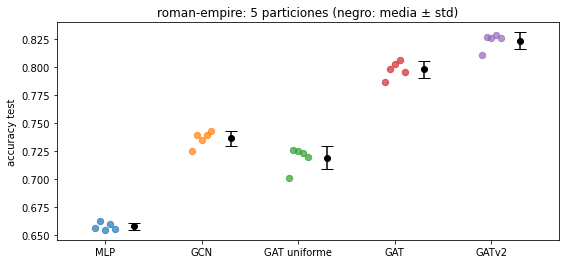

In [8]:
SPLITS = range(5)
MODELOS = list(CAPAS)
resultados, predicciones, modelos_split0 = [], {m: {} for m in MODELOS}, {}

t0 = time.time()
for split in SPLITS:
    _, _, test_mask = masks(split)
    for nombre in MODELOS:
        model, _ = train(nombre, split, seed=split)
        with torch.no_grad():
            pred = model(g, features).argmax(1)
        predicciones[nombre][split] = pred.cpu()
        resultados.append({"modelo": nombre, "partición": split,
                           "accuracy": (pred[test_mask] == labels[test_mask]).float().mean().item()})
        if split == 0:
            modelos_split0[nombre] = model
print(f"Tiempo: {time.time() - t0:.0f} s\n")

res = pd.DataFrame(resultados)
tabla = res.groupby("modelo", sort=False)["accuracy"].agg(["mean", "std"])
pareado = res.pivot(index="partición", columns="modelo", values="accuracy")
for base in ["GCN", "GAT uniforme"]:
    tabla[f"vs {base}"] = [(pareado[m] - pareado[base]).mean() for m in tabla.index]
tabla["gana a GCN en"] = [f"{int((pareado[m] > pareado['GCN']).sum())}/{len(SPLITS)}" for m in tabla.index]
display(tabla.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
for x, nombre in enumerate(MODELOS):
    vals = res.loc[res["modelo"] == nombre, "accuracy"]
    ax.scatter(np.full(len(vals), x) + np.linspace(-0.1, 0.1, len(vals)), vals, s=40, alpha=0.7)
    ax.errorbar(x + 0.3, vals.mean(), yerr=vals.std(), fmt="o", color="black", capsize=6)
ax.set(xticks=range(len(MODELOS)), xticklabels=MODELOS, xlim=(-0.5, len(MODELOS) - 0.3),
       ylabel="accuracy test", title="roman-empire: 5 particiones (negro: media ± std)")
plt.show()

**Lectura: aquí la atención sí importa.**
- **GAT supera a GCN por 6.2 puntos** (0.798 contra 0.736) y gana en las 5 particiones, con desviaciones de ~0.007. Los números reproducen los del paper de Platonov et al. (GAT 80.9, GCN 73.7).
- El control clave es **GAT uniforme**: la misma arquitectura, los mismos parámetros y el mismo entrenamiento, con los $\alpha_{ij}$ fijados en $1/d_i$. Queda en **0.719**, incluso por debajo de GCN. Sin atención, todo lo demás de GAT no sirve de nada: los **7.9 puntos** de diferencia vienen de la atención.
- **GATv2** agrega 2.5 puntos más (0.823). Más abajo vemos por qué.
- El grafo también importa: GCN le saca 7.9 puntos al MLP, que mira solo la palabra.

## ¿Qué clases ganan con la atención?

Comparamos el recall por clase de GAT y GCN, promediado sobre las 5 particiones. La tabla va ordenada por la ganancia de GAT.

In [9]:
from sklearn.metrics import classification_report, recall_score

labels_cpu = labels.cpu()


def recall_por_clase(nombre):
    r = []
    for split in SPLITS:
        _, _, tm = masks(split)
        tm = tm.cpu()
        r.append(recall_score(labels_cpu[tm], predicciones[nombre][split][tm],
                              labels=range(num_classes), average=None, zero_division=0))
    return np.mean(r, axis=0)


rec = pd.DataFrame({"frecuencia": frec / frec.sum(),
                    "grado medio": [grado[labels_cpu == c].float().mean().item() for c in range(num_classes)],
                    "recall MLP": recall_por_clase("MLP"),
                    "recall GCN": recall_por_clase("GCN"),
                    "recall GAT": recall_por_clase("GAT")}, index=CLASES)
rec["GAT - GCN"] = rec["recall GAT"] - rec["recall GCN"]
rec["GCN - MLP"] = rec["recall GCN"] - rec["recall MLP"]
rec = rec.sort_values("GAT - GCN", ascending=False)
print(f"GAT mejora el recall en {(rec['GAT - GCN'] > 0).sum()} de {num_classes} clases")
(rec.style
 .background_gradient(cmap="RdYlGn", subset=["GAT - GCN", "GCN - MLP"], vmin=-0.3, vmax=0.3)
 .background_gradient(cmap="Blues", subset=["recall MLP", "recall GCN", "recall GAT"], vmin=0, vmax=1)
 .format("{:.3f}"))

GAT mejora el recall en 18 de 18 clases


,frecuencia,grado medio,recall MLP,recall GCN,recall GAT,GAT - GCN,GCN - MLP
rol 14,0.015,3.453,0.000,0.471,0.761,0.290,0.471
rol 15,0.014,2.545,0.724,0.709,0.885,0.175,-0.015
rol 6,0.055,2.877,0.341,0.574,0.715,0.141,0.233
rol 8,0.038,3.404,0.101,0.441,0.550,0.109,0.340
rol 10,0.032,2.077,0.258,0.411,0.515,0.104,0.153
rol 9,0.035,2.253,0.866,0.586,0.671,0.085,-0.280
rol 0,0.042,4.363,0.530,0.692,0.771,0.080,0.162
rol 16,0.014,4.321,0.005,0.633,0.708,0.074,0.628
rol 11,0.020,2.290,0.562,0.773,0.847,0.074,0.211
rol 7,0.048,2.379,0.979,0.915,0.981,0.066,-0.064


**Lectura.** GAT mejora el recall en **las 18 clases**, pero se ven dos tipos de rol:

- **Roles que se reconocen por la palabra misma.** El MLP, sin grafo, ya los clasifica bien: `rol 3` 0.994, `rol 7` 0.979, `rol 2` 0.972, `rol 9` 0.866, `rol 4` 0.862. Probablemente son palabras funcionales o de vocabulario muy característico (el dataset no publica los nombres). **GCN los empeora**: `rol 9` baja de 0.866 a 0.586, y `rol 4` de 0.862 a 0.733. Al promediar con pesos fijos, la representación de la palabra se mezcla con la de vecinos de otros roles. GAT recupera casi todo (`rol 7` 0.981, `rol 3` 0.975) porque puede decidir cuánto escuchar a cada vecino.
- **Roles que dependen del contexto.** El MLP no los reconoce: `rol 14` 0.000, `rol 16` 0.005, `rol 8` 0.101, `rol 5` 0.119. Para ellos, el grafo es indispensable. GCN los levanta bastante (`rol 16` a 0.633) y GAT aún más. La mayor ganancia está en `rol 14`: de 0.471 a 0.761.

GAT consigue lo mejor de los dos mundos: **conserva** la información de la palabra cuando basta, y **elige** al vecino relevante cuando hace falta contexto.

## ¿Dónde está la ganancia? Por grado del nodo

Si la atención sirve para **elegir** entre vecinos, debería importar más en los nodos que tienen **más vecinos entre los que elegir**. En este grafo casi todas las palabras tienen al menos 2 vecinas (la anterior y la siguiente en el texto); las que tienen más son las que además participan en dependencias sintácticas. Agrupamos los nodos de test por grado y comparamos el accuracy de los modelos en cada grupo.

modelo,nodos test (por partición),MLP,GCN,GAT uniforme,GAT,GAT - GCN
≤ 2,2367,0.752,0.764,0.744,0.805,0.041
3,2086,0.667,0.756,0.741,0.819,0.063
4-5,1073,0.473,0.660,0.643,0.754,0.094
6+,139,0.338,0.560,0.542,0.696,0.137


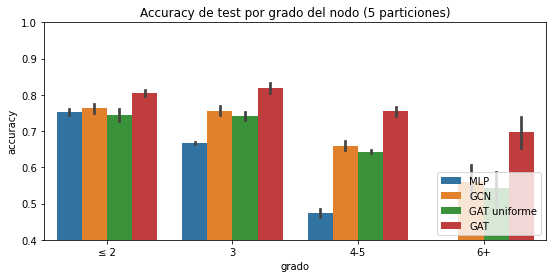

In [10]:
grupos_grado = pd.cut(grado.numpy(), bins=[0, 2, 3, 5, 1000], labels=["≤ 2", "3", "4-5", "6+"])
filas = []
for split in SPLITS:
    _, _, tm = masks(split)
    tm = tm.cpu().numpy()
    for nombre in ["MLP", "GCN", "GAT uniforme", "GAT"]:
        ok = (predicciones[nombre][split].numpy() == labels_cpu.numpy())
        for gr in grupos_grado.categories:
            sel = tm & (grupos_grado == gr)
            filas.append({"modelo": nombre, "grado": gr, "acc": ok[sel].mean(), "n": sel.sum()})
por_grado = pd.DataFrame(filas)
t = (por_grado.pivot_table(index="grado", columns="modelo", values="acc", observed=False)
     .reindex(grupos_grado.categories)[["MLP", "GCN", "GAT uniforme", "GAT"]])
t["GAT - GCN"] = t["GAT"] - t["GCN"]
t.insert(0, "nodos test (por partición)", por_grado[por_grado.modelo == "GAT"].groupby("grado", observed=False)["n"].mean().astype(int))
display(t.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=por_grado, x="grado", y="acc", hue="modelo", errorbar="sd", ax=ax)
ax.set(title="Accuracy de test por grado del nodo (5 particiones)", ylabel="accuracy", ylim=(0.4, 1))
ax.legend(loc="lower right")
plt.show()

**Lectura.** La ventaja de GAT sobre GCN **crece con el grado**: +4.1 puntos en nodos de grado ≤ 2, +6.3 en grado 3, +9.4 en grado 4–5 y **+13.7** en grado 6 o más. Es lo que predice el mecanismo: cuantos más vecinos hay, más importa elegir bien. En cambio, GAT uniforme queda igual o bajo GCN en todos los grupos.

Además, todos los modelos bajan con el grado. Las palabras con muchos dependientes (probablemente verbos y sustantivos núcleo) son más difíciles. El grupo 6+ tiene solo ~140 nodos de test por partición, así que su estimación es más ruidosa.

# ¿Qué aprendió la atención?

## ¿Se aleja la atención del promedio uniforme?

Igual que antes, medimos la **entropía normalizada** de la atención de cada nodo, $H_i / \log d_i$: vale 1 si el nodo reparte la atención en partes iguales entre sus vecinos y 0 si la pone toda en uno solo. Como referencia, calculamos la misma medida para pesos repartidos **al azar** sobre los mismos vecindarios.

Referencia, pesos al azar: entropía media 0.777, nodos con entropía < 0.5: 0.060


entropía media               nodos con entropía < 0.5              
               mean    min    max                     mean    min    max
capa                                                                    
1             0.658  0.398  0.807                    0.303  0.146  0.598
2             0.631  0.505  0.835                    0.334  0.089  0.468
3             0.727  0.588  0.896                    0.222  0.019  0.400

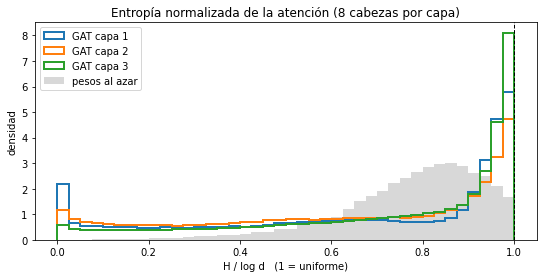

In [11]:
gat = modelos_split0["GAT"]
with torch.no_grad():
    gat(g, features)

deg_total = g.in_degrees().float()   # incluye el self-loop
multi = deg_total >= 2
n = g.num_nodes()


def entropia_normalizada(alpha):
    """alpha: (E,) -> H_i / log d_i para los nodos con al menos 2 vecinos."""
    ent = torch.zeros(n, device=device).index_add_(0, dst.to(device), -alpha * torch.log(alpha.clamp(min=1e-12)))
    return (ent[multi] / torch.log(deg_total[multi])).cpu().numpy()


filas, ent_capas = [], {}
for l, conv in enumerate(gat.convs):
    for k in range(conv.H):
        ent = entropia_normalizada(conv.alpha[:, k, 0])
        ent_capas.setdefault(l, []).append(ent)
        filas.append({"capa": l + 1, "cabeza": k, "entropía media": ent.mean(),
                      "nodos con entropía < 0.5": (ent < 0.5).mean()})
w = -torch.log(torch.rand(g.num_edges(), device=device))
alpha_azar = w / torch.zeros(n, device=device).index_add_(0, dst.to(device), w)[dst.to(device)]
ent_azar = entropia_normalizada(alpha_azar)

tabla_ent = pd.DataFrame(filas).groupby("capa")[["entropía media", "nodos con entropía < 0.5"]].agg(["mean", "min", "max"])
print(f"Referencia, pesos al azar: entropía media {ent_azar.mean():.3f}, nodos con entropía < 0.5: {(ent_azar < 0.5).mean():.3f}")
display(tabla_ent.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, 1, 41)
for l, ents in ent_capas.items():
    ax.hist(np.concatenate(ents), bins=bins, density=True, histtype="step", lw=2, label=f"GAT capa {l + 1}")
ax.hist(ent_azar, bins=bins, density=True, alpha=0.3, color="gray", label="pesos al azar")
ax.axvline(1, color="k", ls="--", lw=1)
ax.set(xlabel="H / log d   (1 = uniforme)", ylabel="densidad", title="Entropía normalizada de la atención (8 cabezas por capa)")
ax.legend()
plt.show()

**Lectura.** A diferencia de Cora, donde la entropía era 1.000 en todas las cabezas, aquí la atención está **lejos de ser uniforme**:
- La entropía media por capa va de 0.63 a 0.73. Es incluso **menor** que la de pesos al azar (0.78).
- La distribución es **bimodal**. Hay un pico en 1, con nodos que reparten la atención de forma pareja, y otro en 0, con nodos que ponen **toda** la atención en un solo vecino. En la primera capa, el 30% de los nodos tiene entropía < 0.5; con pesos al azar sería el 6%.
- Las cabezas se **especializan**. En la primera capa, la entropía media varía entre 0.40 y 0.81 según la cabeza: unas concentran mucho y otras promedian.

## Prueba causal: apagar la atención del modelo ya entrenado

La entropía muestra que la atención **no es uniforme**, pero no prueba que el modelo la **use**. Hacemos una intervención directa: tomamos la GAT ya entrenada y, **sin tocar ningún peso**, reemplazamos su atención por la uniforme (`uniforme=True`), primero en una capa a la vez y después en todas. Si el accuracy cae, el modelo depende de a quién pone atención.

In [12]:
_, _, tm0 = masks(0)
base_acc = evaluate(gat, tm0)
filas = [{"intervención": "ninguna (GAT entrenada)", "accuracy test": base_acc}]
for capas in [[0], [1], [2], [0, 1, 2]]:
    for l in capas:
        gat.convs[l].uniforme = True
    filas.append({"intervención": "atención uniforme en capa(s) " + ", ".join(str(l + 1) for l in capas),
                  "accuracy test": evaluate(gat, tm0)})
    for l in capas:
        gat.convs[l].uniforme = False
interv = pd.DataFrame(filas)
interv["cambio"] = interv["accuracy test"] - base_acc
interv.round(4)

,intervención,accuracy test,cambio
0,ninguna (GAT entrenada),0.7864,0.0000
1,atención uniforme en capa(s) 1,0.3069,-0.4795
2,atención uniforme en capa(s) 2,0.7293,-0.0572
3,atención uniforme en capa(s) 3,0.7451,-0.0413
4,"atención uniforme en capa(s) 1, 2, 3",0.2455,-0.5409


**Lectura.** El modelo **depende** de su atención. Si se reemplaza por la uniforme solo en la primera capa, el accuracy cae de 0.786 a **0.307**. En las tres capas cae a 0.246, muy por debajo incluso del MLP. En las capas 2 y 3 la caída es menor (−5.7 y −4.1 puntos): la selección más importante ocurre al principio, cuando cada palabra decide de qué vecinas toma información.

Ojo con la interpretación: esto **no** mide cuánto vale la atención. Un modelo entrenado desde el principio sin atención (GAT uniforme) llega a 0.719, no a 0.307. Lo que muestra es que los demás pesos de esta GAT se ajustaron a una agregación selectiva, y sin ella el modelo deja de funcionar. La comparación justa del valor de la atención es la tabla de las 5 particiones.

## ¿Cuánto se mira cada palabra a sí misma?

El self-loop permite que el nodo decida cuánto pesa su propia representación. Con atención uniforme ese peso es $1/d_i$. Comparamos el peso que asigna GAT al self-loop (promedio de cabezas) con ese valor uniforme.

In [13]:
with torch.no_grad():
    gat(g, features)   # recalcula la atención: la celda anterior dejó guardada la versión uniforme
es_self = (src == dst).to(device)
nodos_self = dst.to(device)[es_self]
filas = []
for l, conv in enumerate(gat.convs):
    a_self = conv.alpha[es_self, :, 0].mean(1)
    unif = 1 / deg_total[nodos_self]
    filas.append({"capa": l + 1, "peso self-loop (GAT)": a_self.mean().item(), "1/d (uniforme)": unif.mean().item(),
                  "nodos donde self > 1/d": (a_self > unif).float().mean().item()})
pd.DataFrame(filas).round(3)

,capa,peso self-loop (GAT),1/d (uniforme),nodos donde self > 1/d
0,1,0.296,0.271,0.569
1,2,0.264,0.271,0.446
2,3,0.239,0.271,0.243


**Lectura.** En la primera capa, las palabras se ponen **más** atención a sí mismas que el reparto uniforme (0.296 contra 0.271; en el 57% de los nodos). En la tercera capa, **menos** (0.239; solo el 24%). Tiene sentido: al principio la palabra conserva su propia información, y en las capas siguientes mira hacia afuera. De todos modos, las diferencias promedio son modestas. La selectividad que mostró la entropía está sobre todo en **cuál vecino** escuchar, no en cuánto escucharse a sí misma.

## Atención estática vs dinámica: por qué GATv2 rinde más

En GAT el puntaje es $e_{ij} = \text{LeakyReLU}(a_{src}^\top z_j + a_{dst}^\top z_i)$. El término $a_{dst}^\top z_i$ es el **mismo para todos los vecinos** de $i$, y la LeakyReLU es monótona. Entonces el **orden** de los vecinos lo decide solo $a_{src}^\top z_j$, una puntuación global de cada vecino que no depende de quién pregunta. Brody et al. (2022) llaman a esto **atención estática**: si la palabra $j$ es la "más interesante" para un nodo, lo es para todos los nodos que la tienen de vecina.

GATv2 aplica la no linealidad **antes** del producto con $a$: $e_{ij} = a^\top \text{LeakyReLU}(W_s h_j + W_d h_i)$. Ahora el puntaje depende de la **combinación** de $i$ y $j$, y distintos nodos pueden preferir vecinos distintos. Es **atención dinámica**.

Lo podemos verificar en los modelos entrenados. Tomamos los pares de nodos $(i, i')$ que tienen **dos vecinos en común** $j, k$ (sin contar el self-loop) y vemos si ambos los ordenan igual (cuál de los dos recibe más atención). Con atención estática deberían coincidir siempre.

In [14]:
def acuerdo_de_orden(model, capa=0, cabeza=0, max_pares=20000, seed=0):
    """Fracción de pares (i, i') con vecinos comunes j, k donde ambos ordenan j y k igual."""
    with torch.no_grad():
        model(g, features)
    alpha = model.convs[capa].alpha[:, cabeza, 0].cpu().numpy()
    s, d = src.numpy(), dst.numpy()
    atencion = {}
    for e in np.where(s != d)[0]:
        atencion.setdefault(d[e], {})[s[e]] = alpha[e]
    # para cada vecino j, qué nodos lo escuchan
    oyentes = {}
    for i, vec in atencion.items():
        for j in vec:
            oyentes.setdefault(j, []).append(i)
    rng = np.random.RandomState(seed)
    iguales = total = 0
    nodos = [i for i in atencion if len(atencion[i]) >= 2]
    for _ in range(max_pares):
        i = nodos[rng.randint(len(nodos))]
        j, k = rng.choice(list(atencion[i]), 2, replace=False)
        otros = [x for x in oyentes[j] if x != i and k in atencion[x]]
        if not otros:
            continue
        i2 = otros[rng.randint(len(otros))]
        iguales += (atencion[i][j] > atencion[i][k]) == (atencion[i2][j] > atencion[i2][k])
        total += 1
    return iguales / max(total, 1), total


filas = []
for nombre in ["GAT", "GATv2"]:
    for capa in range(3):
        acuerdo, total = acuerdo_de_orden(modelos_split0[nombre], capa=capa)
        filas.append({"modelo": nombre, "capa": capa + 1, "pares comparados": total,
                      "mismo orden de vecinos": acuerdo})
pd.DataFrame(filas).pivot(index="capa", columns="modelo", values="mismo orden de vecinos").round(3)

modelo,GAT,GATv2
capa,,
1,1.0,0.662
2,1.0,0.824
3,1.0,0.879


**Lectura.** La teoría se cumple exactamente. En GAT, dos nodos que comparten vecinos $j$ y $k$ los ordenan **siempre igual** (1.000 en las tres capas): la atención es estática. En GATv2 coinciden solo en el 66–88% de los casos, así que cada nodo puede preferir un vecino distinto.

En sintaxis esto importa. Una misma palabra puede ser el vecino relevante para una de sus vecinas y no para otra: un sustantivo es clave para su determinante, pero no necesariamente para la palabra que lo sigue. La atención estática no puede expresar eso, y la dinámica sí. Así se explican los 2.5 puntos extra de GATv2.

## Embeddings (t-SNE)

Proyectamos la representación final (antes de la capa de salida) de 4.000 nodos de test, para GCN y GAT, coloreando por rol sintáctico. Se muestran los 8 roles más frecuentes; el resto va en gris.

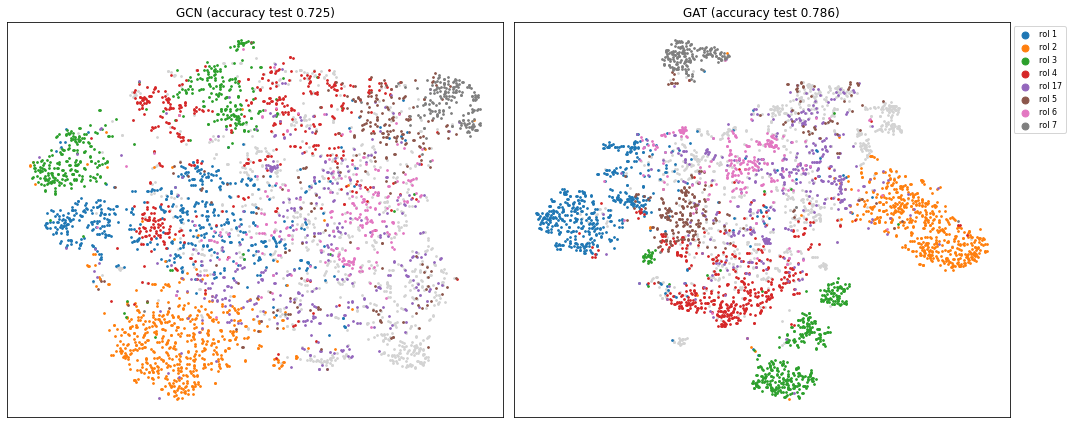

In [15]:
from sklearn.manifold import TSNE

rng = np.random.RandomState(0)
idx_test = np.where(tm0.cpu().numpy())[0]
muestra = rng.choice(idx_test, 4000, replace=False)
top = np.argsort(-frec)[:8]
paleta = sns.color_palette("tab10", 8)
lab_m = labels_cpu.numpy()[muestra]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, nombre in zip(axes, ["GCN", "GAT"]):
    with torch.no_grad():
        _, hid = modelos_split0[nombre](g, features, return_hidden=True)
    emb = TSNE(n_components=2, perplexity=30, random_state=0).fit_transform(hid[muestra].cpu().numpy())
    otros = ~np.isin(lab_m, top)
    ax.scatter(emb[otros, 0], emb[otros, 1], s=3, color="lightgray")
    for c, col in zip(top, paleta):
        sel = lab_m == c
        ax.scatter(emb[sel, 0], emb[sel, 1], s=3, color=col, label=CLASES[c])
    acc = res[(res.modelo == nombre) & (res["partición"] == 0)]["accuracy"].item()
    ax.set_title(f"{nombre} (accuracy test {acc:.3f})")
    ax.set_xticks([]); ax.set_yticks([])
axes[1].legend(markerscale=4, fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

**Lectura.** En GCN los roles aparecen como nubes que se superponen en el centro. En GAT forman grupos **más compactos y separados**: `rol 7`, `rol 2`, `rol 1` y `rol 3` quedan casi aislados. La representación que construye la atención separa mejor los roles, en línea con la diferencia de accuracy en esta partición (0.725 contra 0.786).

# Contraste: los mismos modelos en Cora

Para cerrar, corremos exactamente los mismos 5 modelos en **Cora** (split estándar, 5 semillas). Si la explicación es correcta, ahí la atención no debería aportar: el vecindario ya es homogéneo y no hay nada que elegir.

In [16]:
from dgl.data import CoraGraphDataset

g_roman, feat_roman, lab_roman = g, features, labels
cora = CoraGraphDataset(verbose=False)[0]
cora = dgl.add_self_loop(dgl.remove_self_loop(cora)).to(device)
g, features, labels = cora, cora.ndata["feat"], cora.ndata["label"]
for k in ("train_mask", "val_mask", "test_mask"):
    g.ndata[k] = g.ndata[k].unsqueeze(1)   # una sola "partición", mismo formato que roman-empire
num_classes_roman, num_classes = num_classes, 7

filas = []
for nombre in MODELOS:
    for seed in range(5):
        model, _ = train(nombre, split=0, seed=seed, epochs=200, dim=64)
        _, _, tm = masks(0)
        filas.append({"modelo": nombre, "semilla": seed, "accuracy": evaluate(model, tm)})
res_cora = pd.DataFrame(filas)

g, features, labels, num_classes = g_roman, feat_roman, lab_roman, num_classes_roman

comparacion = pd.DataFrame({
    "roman-empire": res.groupby("modelo", sort=False)["accuracy"].mean(),
    "Cora": res_cora.groupby("modelo", sort=False)["accuracy"].mean(),
})
comparacion["Cora std"] = res_cora.groupby("modelo", sort=False)["accuracy"].std()
comparacion.round(4)

,roman-empire,Cora,Cora std
modelo,,,
MLP,0.6577,0.4782,0.0378
GCN,0.7362,0.7432,0.0288
GAT uniforme,0.7190,0.7592,0.0152
GAT,0.7979,0.7488,0.0208
GATv2,0.8233,0.7582,0.0090


**Lectura: en Cora, empate.** GCN, GAT uniforme, GAT y GATv2 quedan entre 0.743 y 0.759, con desviaciones de 1 a 3 puntos entre semillas. Ninguna diferencia supera el ruido, y GAT uniforme incluso queda arriba de GAT. (El MLP rinde poco con esta arquitectura y 140 nodos de entrenamiento, pero no es el foco aquí.)

Es el mismo resultado de la versión anterior de este notebook, y ahora se entiende. **La atención no es mejor en general.** Es mejor cuando hay vecinos que conviene ignorar y el contenido permite reconocerlos. En Cora el vecindario ya es homogéneo; en roman-empire, no.

## En resumen

1. En **roman-empire**, GAT supera a GCN por **6.2 puntos** y GATv2 por **8.7**, en las 5 particiones.
2. El control **GAT uniforme** (misma arquitectura, sin atención) queda al nivel de GCN. La ganancia es de la **atención**, no de la arquitectura ni del entrenamiento.
3. La atención aprendida es **selectiva**: entropía baja, cabezas especializadas, y el modelo colapsa si se le quita. La ventaja crece con el número de vecinos entre los que elegir.
4. GAT ayuda en las **dos** situaciones donde GCN falla: cuando basta la palabra misma (GCN la diluye) y cuando hace falta un vecino específico.
5. GATv2 rinde más porque su atención es **dinámica**. En GAT, el orden de los vecinos es el mismo para todos los nodos (lo verificamos: 100% de acuerdo).
6. En **Cora** los cinco modelos empatan. La atención vale cuando el vecindario es **heterogéneo** y el contenido de los nodos permite distinguir qué vecinos importan.